## Лабораторная 4

1. Сгенерировать набор данных при помощи make_classification из sklearn.
2. Построить нейронную сеть для решения задачи классификации (можете использовать лабораторную 3).
3. Исследовать влияние различных классификаторов на качество модели (SGD, Adam, RMSProp), записать выводы.
4. Добавить к модели метод регуляризации Dropout и повторить пункт 3 уже с ним.

*Дополнительное задание:
Повторить пункты 2-4 для набора данных MNIST.*

In [68]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from matplotlib import pyplot as plt
from keras.datasets import mnist

# Генерируем данные методом make_classification

In [ ]:
x, y = make_classification(
    n_samples=10000, 
    n_features=50,
    n_informative=30,
    n_redundant=20,
    n_classes=5,
    random_state=1234)
x = StandardScaler().fit_transform(x)
y = np.array(pd.get_dummies(y), dtype="float")

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Обучаем модели для задачи make_classification

In [49]:
architecture = [
    keras.layers.Input((50, )),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(5, activation='sigmoid')
]

architecture_w_dropout = [
    keras.layers.Input((50, )),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(5, activation='sigmoid')
]

In [46]:
optimizers = {"SGD": keras.optimizers.SGD(),
              "Adam": keras.optimizers.Adam(),
              "RMSProp": keras.optimizers.RMSprop()}

In [47]:
# Обучаем модели без Dropout

histories = {}

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential(architecture)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test))
    histories[optim_name] = history

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5013 - loss: 1.2329 - val_accuracy: 0.7105 - val_loss: 0.7457
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7307 - loss: 0.7205 - val_accuracy: 0.7565 - val_loss: 0.6334
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7760 - loss: 0.6090 - val_accuracy: 0.7800 - val_loss: 0.5737
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8097 - loss: 0.5130 - val_accuracy: 0.8000 - val_loss: 0.5389
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8231 - loss: 0.4890 - val_accuracy: 0.8095 - val_loss: 0.5266
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8280 - loss: 0.4807 - val_accuracy: 0.8175 - val_loss: 0.5259
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8359 - loss: 0.4648 - val_accuracy: 0.8080 - val_loss: 0.5097
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8322 - loss: 0.4497 - val_accu

In [51]:
# Обучаем модели с Dropout

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential(architecture_w_dropout)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test))
    histories[f"dropout_{optim_name}"] = history

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4501 - loss: 1.3748 - val_accuracy: 0.6610 - val_loss: 0.9109
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5820 - loss: 1.0132 - val_accuracy: 0.7050 - val_loss: 0.7861
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6148 - loss: 0.9348 - val_accuracy: 0.7135 - val_loss: 0.7386
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6321 - loss: 0.9017 - val_accuracy: 0.7225 - val_loss: 0.7071
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6436 - loss: 0.8581 - val_accuracy: 0.7280 - val_loss: 0.7011
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6450 - loss: 0.8701 - val_accuracy: 0.7280 - val_loss: 0.7030
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6483 - loss: 0.8508 - val_accuracy: 0.7340 - val_loss: 0.6956
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6451 - loss: 0.8519 - val_accu

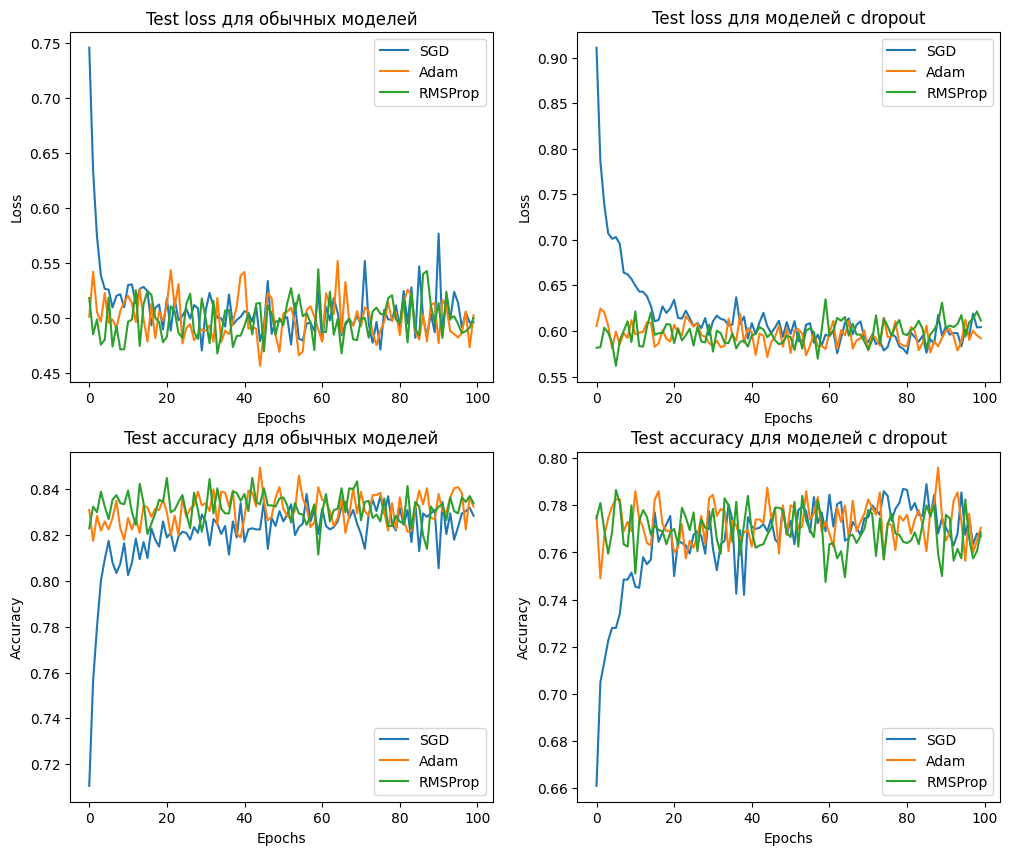

In [65]:
# Строим графики

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

for optim_name in optimizers.keys():
    ax1.plot(histories[optim_name].history[f"val_loss"], label=optim_name)
ax1.set_title('Test loss для обычных моделей')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

for optim_name in optimizers.keys():
    ax2.plot(histories[f"dropout_{optim_name}"].history[f"val_loss"], label=optim_name)
ax2.set_title('Test loss для моделей с dropout')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

for optim_name in optimizers.keys():
    ax3.plot(histories[optim_name].history[f"val_accuracy"], label=optim_name)
ax3.set_title('Test accuracy для обычных моделей')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.legend()

for optim_name in optimizers.keys():
    ax4.plot(histories[f"dropout_{optim_name}"].history[f"val_accuracy"], label=optim_name)
ax4.set_title('Test accuracy для моделей с dropout')
ax4.set_xlabel('Epochs')
ax4.set_ylabel('Accuracy')
ax4.legend()

plt.show()

# Загружаем и предобрабатываем датасет MNIST

In [69]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [70]:
x_train = np.reshape(x_train / 255, (60000, 784))
x_test = np.reshape(x_test / 255, (10000, 784))
y_train = np.array(pd.get_dummies(y_train))
y_test = np.array(pd.get_dummies(y_test))

# Обучаем модели для задачи MNIST

In [74]:
architecture = [
    keras.layers.Input((28 * 28, )),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
]

architecture_w_dropout = [
    keras.layers.Input((28 * 28, )),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(10, activation='sigmoid')
]

In [75]:
optimizers = {"SGD": keras.optimizers.SGD(),
              "Adam": keras.optimizers.Adam(),
              "RMSProp": keras.optimizers.RMSprop()}

In [77]:
# Обучаем модели без Dropout

histories_mnist = {}

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential(architecture)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test))
    histories_mnist[optim_name] = history

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8866 - loss: 0.3691 - val_accuracy: 0.9324 - val_loss: 0.2296
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9448 - loss: 0.1901 - val_accuracy: 0.9548 - val_loss: 0.1642
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9542 - loss: 0.1556 - val_accuracy: 0.9517 - val_loss: 0.1695
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9543 - loss: 0.1519 - val_accuracy: 0.9537 - val_loss: 0.1718
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9573 - loss: 0.1420 - val_accuracy: 0.9454 - val_loss: 0.1958
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9563 - loss: 0.1398 - val_accuracy: 0.9440 - val_loss: 0.1790
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9579 - loss: 0.1304 - val_accuracy: 0.9460 - val_loss: 0.1849
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9595 - loss: 0.124

KeyboardInterrupt: 

In [ ]:
# Обучаем модели с Dropout

for optim_name in optimizers.keys():
    # Для каждого оптимизатора
    model = keras.models.Sequential(architecture_w_dropout)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
                loss='crossentropy',
                metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=50, validation_data=(x_test, y_test))
    histories_mnist[f"dropout_{optim_name}"] = history

In [ ]:
# Строим графики

fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2, figsize=(12, 8))

for optim_name in optimizers.keys():
    ax1.plot(histories_mnist[optim_name].history[f"val_loss"], label=optim_name)
ax1.set_title('Test loss для обычных моделей')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

for optim_name in optimizers.keys():
    ax2.plot(histories_mnist[f"dropout_{optim_name}"].history[f"val_loss"], label=optim_name)
ax2.set_title('Test loss для моделей с dropout')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

for optim_name in optimizers.keys():
    ax3.plot(histories_mnist[optim_name].history[f"val_accuracy"], label=optim_name)
ax3.set_title('Test accuracy для обычных моделей')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Accuracy')
ax3.legend()

for optim_name in optimizers.keys():
    ax4.plot(histories_mnist[f"dropout_{optim_name}"].history[f"val_accuracy"], label=optim_name)
ax4.set_title('Test accuracy для моделей с dropout')
ax4.set_xlabel('Epochs')
ax4.set_ylabel('Accuracy')
ax4.legend()

plt.show()